# 4.0 Modelling

Trains and tunes the four regression models from the project objectives. Each
model gets its own section below and all of them are scored with the same
`evaluate_model()` helper so Section 5 can compare them like for like.

**Shared Setup must be run first** â€” it rebuilds the leakage-safe train/test
split from Section 3 and defines `XX_train` / `XX_test` / `y_train` / `y_test`
that every model section uses.

## Shared Setup

Reproduces the Section 3.5 pipeline exactly as in `02_data_preparation.ipynb`:
clean → treat outliers → split 80:20 → *then* transform. `transform()` and the
preprocessor are fit on the training split only, so cityname's target
encoding, the one-hot encoder and the scaler never see test data.

In [2]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import matplotlib.pyplot as plt
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from src.final_dataset_output import build_prepared_dataset, RAW_CSV_PATH
from src.data_transformation import transform, get_engineered_feature_lists, build_preprocessor

# notebooks/ runs with a different cwd than the repo root
RAW_CSV_PATH = "../" + RAW_CSV_PATH

# Where trained models/preprocessors are cached to disk. The Streamlit app loads
# straight from these fixed filenames, so they stay stable across reruns.
MODELS_DIR = pathlib.Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

prepared_df = build_prepared_dataset(raw_csv_path=RAW_CSV_PATH, verbose=False)

# Split BEFORE any transformation
X = prepared_df.drop(columns=["price"])
y = prepared_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_transformed = transform(X_train)
X_test_transformed = transform(X_test)

numeric, categorical, city = get_engineered_feature_lists(X_train_transformed)

# scale_numeric=True — required by the scale-sensitive models (Linear Regression, KNN).
# Tree-based sections may rebuild the preprocessor with scale_numeric=False.
preprocessor = build_preprocessor(numeric, categorical, city, scale_numeric=True)

# TargetEncoder (used for cityname) is supervised, so fit_transform needs y_train.
XX_train = preprocessor.fit_transform(X_train_transformed, y_train)
XX_test = preprocessor.transform(X_test_transformed)

# Fitting this preprocessor is cheap, so it's always refit here rather than cached —
# only the slow models below (KNN/RF/XGBoost) get the retrain-flag treatment.
# Linear Regression and KNN both consume XX_train/XX_test, so they share this one file.
joblib.dump(preprocessor, MODELS_DIR / "preprocessor_scaled.pkl")

print("Encoded train:", XX_train.shape)
print("Encoded test :", XX_test.shape)

Encoded train: (79075, 76)
Encoded test : (19769, 76)


c:\Users\User\Documents\GitHub\apartment_rental_price_prediction\rent_env\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


---

## Linear Regression Baseline

Linear Regression is the baseline model. It estimates rent as a linear combination of the prepared property features. It uses the scaled feature matrix from Shared Setup and has no hyperparameters to tune, so it gives the other models a simple, interpretable performance benchmark.

In [5]:
from sklearn.linear_model import LinearRegression
from src.modelling import evaluate_model

# Training is near-instant, but this still follows the same cache pattern as the
# slower models below for consistency — flip to True after changing anything
# upstream (e.g. the feature engineering) that should produce a new model.
RETRAIN_LINEAR = False

linear_path = MODELS_DIR / "linear_regression.pkl"

if RETRAIN_LINEAR or not linear_path.exists():
    linear_baseline = LinearRegression()
    linear_baseline.fit(XX_train, y_train)
    joblib.dump(linear_baseline, linear_path)
    print("Trained and saved Linear Regression ->", linear_path)
else:
    linear_baseline = joblib.load(linear_path)
    print("Loaded cached Linear Regression <-", linear_path)

linear_baseline_metrics = evaluate_model(linear_baseline, XX_test, y_test)

print("Linear Regression baseline (held-out test set)")
print(f"RMSE : ${linear_baseline_metrics['rmse']:,.2f}")
print(f"MAE  : ${linear_baseline_metrics['mae']:,.2f}")
print(f"R2   : {linear_baseline_metrics['r2']:.4f}")

Loaded cached Linear Regression <- ..\models\linear_regression.pkl
Linear Regression baseline (held-out test set)
RMSE : $515.91
MAE  : $286.97
R2   : 0.6216


**Figure: predicted vs actual price — Linear Regression baseline diagnostic.**
Each point is one held-out test listing. The red line is `y = x` (a perfect prediction). This establishes a visual benchmark for the KNN and Random Forest diagnostics below.

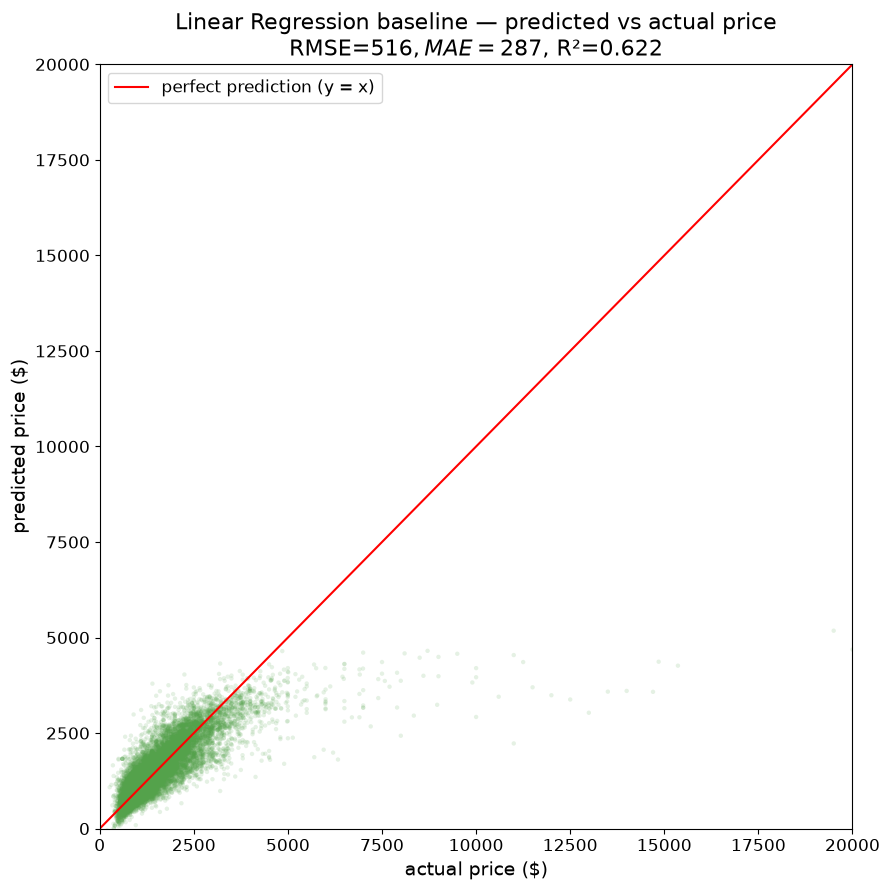

In [6]:
y_pred = linear_baseline_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#54A24B", edgecolors="none")
limits = [0, max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"Linear Regression baseline — predicted vs actual price\n"
             f"RMSE=${linear_baseline_metrics['rmse']:,.0f}, MAE=${linear_baseline_metrics['mae']:,.0f}, "
             f"R²={linear_baseline_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/linear_regression_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

---

## KNN Modelling

K-Nearest Neighbours predicts a listing's rent from the mean rent of its most
similar listings in feature space. It is scale-sensitive, so it uses the scaled
matrices built above. `n_neighbors` controls the bias/variance trade-off (small
k = low bias, high variance) and `weights` decides whether closer neighbours
count more, so both are tuned by 5-fold cross-validation.

In [ ]:
from src.modelling import train_knn, evaluate_model, to_dense

# KNN has no sparse fast path densify once here and reuse for training and scoring.
XX_train_knn = to_dense(XX_train)
XX_test_knn = to_dense(XX_test)

# Flip to True whenever KNN_PARAM_GRID (in src/modelling.py) or anything upstream
# of it changes — otherwise the cached grid search below is loaded instead of rerun.
RETRAIN_KNN = False

knn_path = MODELS_DIR / "knn.pkl"

if RETRAIN_KNN or not knn_path.exists():
    knn_grid = train_knn(XX_train_knn, y_train, cv=5)
    # Dumping the whole GridSearchCV (not just best_estimator_) keeps cv_results_
    # and best_params_ available below even when this cell is skipped on a later run.
    joblib.dump(knn_grid, knn_path)
    print("Trained and saved KNN ->", knn_path)
else:
    knn_grid = joblib.load(knn_path)
    print("Loaded cached KNN <-", knn_path)

print("Best parameters :", knn_grid.best_params_)
print(f"Best CV RMSE    : ${-knn_grid.best_score_:,.2f}")

Trained and saved KNN -> ..\models\knn.pkl
Best parameters : {'n_neighbors': 10, 'weights': 'distance'}
Best CV RMSE    : $434.87


**Figure: k vs CV RMSE evidence for hyperparameter search.**
Cross-validated RMSE for every `n_neighbors` tried, with `uniform` and
`distance` weighting shown separately. The minimum of the lower curve is the
selected model.

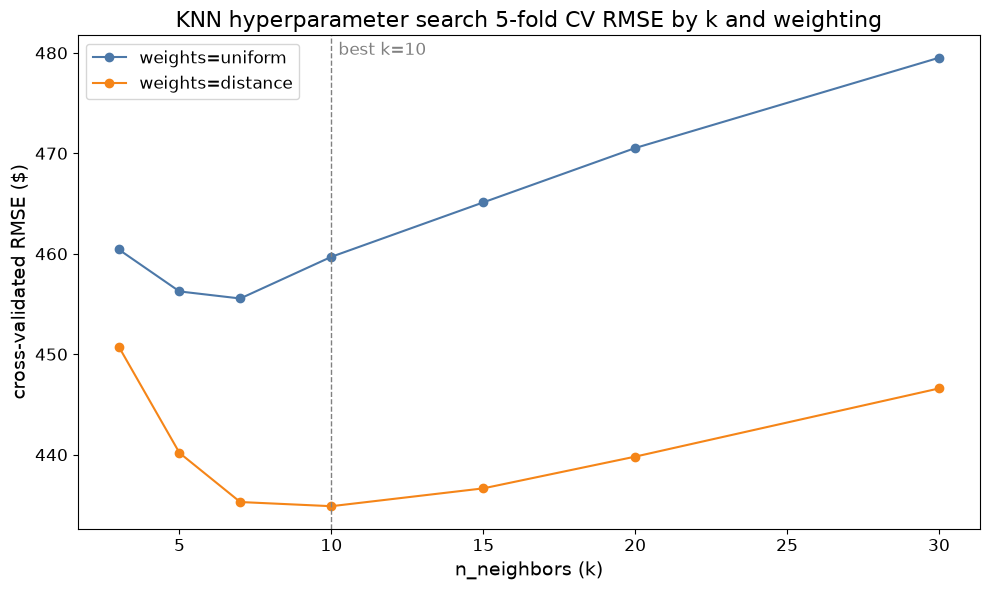

In [16]:
results = knn_grid.cv_results_
fig, ax = plt.subplots(figsize=(10, 6))

for weight, color in [("uniform", "#4C78A8"), ("distance", "#F58518")]:
    mask = np.array(results["param_weights"]) == weight
    ks = np.array(results["param_n_neighbors"])[mask]
    rmse = -np.array(results["mean_test_score"])[mask]
    order = np.argsort(ks)
    ax.plot(ks[order], rmse[order], marker="o", color=color, label=f"weights={weight}")

best_k = knn_grid.best_params_["n_neighbors"]
ax.axvline(best_k, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"best k={best_k}", xy=(best_k, ax.get_ylim()[1]),
            xytext=(5, -14), textcoords="offset points", fontsize=12, color="grey")

ax.set_xlabel("n_neighbors (k)", fontsize=14)
ax.set_ylabel("cross-validated RMSE ($)", fontsize=14)
ax.set_title("KNN hyperparameter search 5-fold CV RMSE by k and weighting", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/knn_k_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [17]:
knn_metrics = evaluate_model(knn_grid.best_estimator_, XX_test_knn, y_test)

print(f"RMSE : ${knn_metrics['rmse']:,.2f}")
print(f"MAE  : ${knn_metrics['mae']:,.2f}")
print(f"R2   : {knn_metrics['r2']:.4f}")

RMSE : $458.12
MAE  : $222.76
R2   : 0.7016


**Figure: predicted vs actual price KNN diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

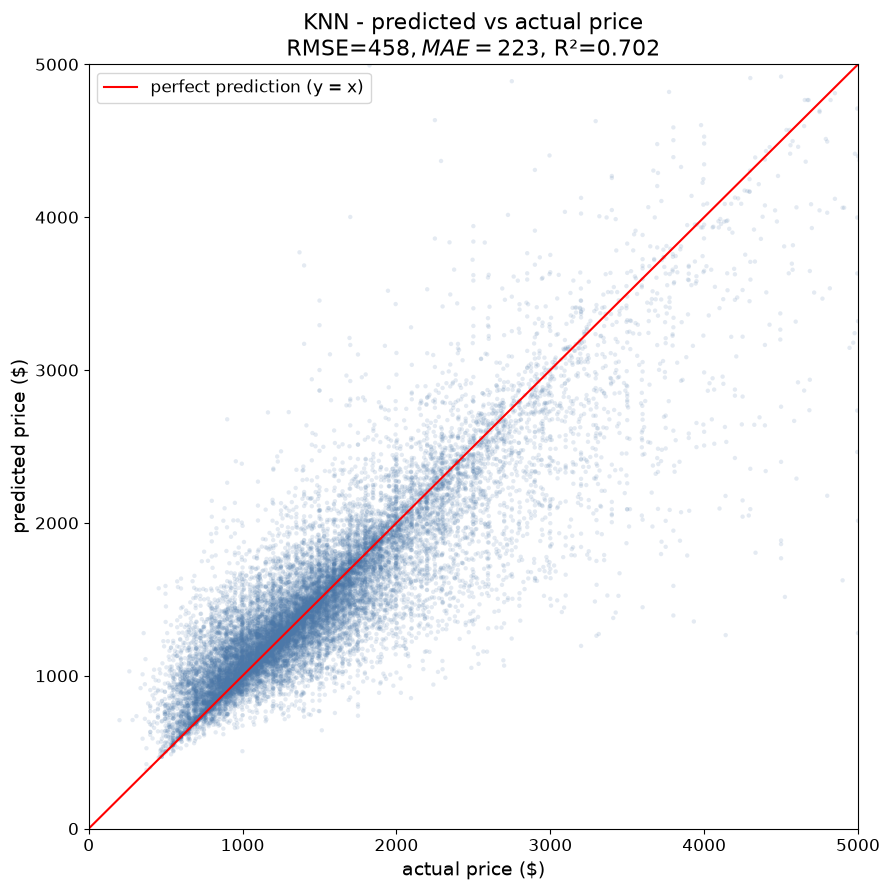

In [ ]:
y_pred = knn_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C78A8", edgecolors="none")

limits = [0, 5000]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"KNN - predicted vs actual price\n"
             f"RMSE=${knn_metrics['rmse']:,.0f}, MAE=${knn_metrics['mae']:,.0f}, "
             f"R\u00b2={knn_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
plt.show()

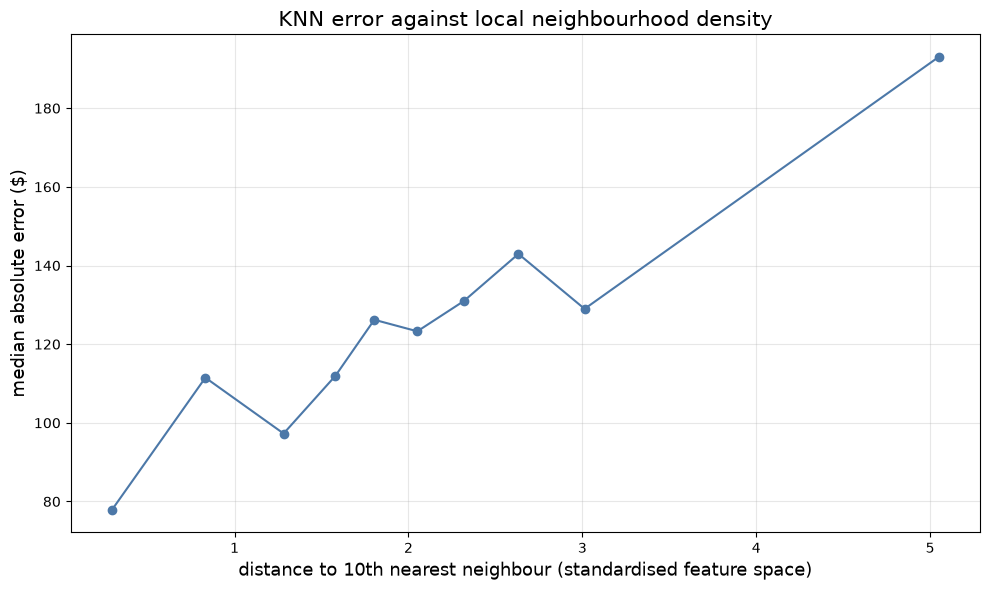

In [19]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# distance to the 10th nearest training neighbour for each test listing
nn = NearestNeighbors(n_neighbors=10).fit(XX_train_knn)
distances, _ = nn.kneighbors(XX_test_knn)
kth_distance = distances[:, -1]

abs_error = np.abs(np.asarray(y_test) - knn_metrics["predictions"])

# decile bins by neighbour distance, median error per bin
edges = np.quantile(kth_distance, np.linspace(0, 1, 11))
idx = np.clip(np.digitize(kth_distance, edges[1:-1]), 0, 9)
median_err = [np.median(abs_error[idx == i]) for i in range(10)]
centres = [(edges[i] + edges[i + 1]) / 2 for i in range(10)]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(centres, median_err, marker="o", color="#4C78A8")
ax.set_xlabel("distance to 10th nearest neighbour (standardised feature space)", fontsize=13)
ax.set_ylabel("median absolute error ($)", fontsize=13)
ax.set_title("KNN error against local neighbourhood density", fontsize=15)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


---

## Random Forest Modelling

A Random Forest is an ensemble of decision trees, each trained on a bootstrap
sample of the data and a random subset of features; predictions are the average
over trees. The ensemble variance falls as more trees are added, and
`max_depth` / `min_samples_leaf` control how deep each tree can grow (the
bias/variance trade-off). Trees are scale-invariant, so this section rebuilds
the preprocessor with `scale_numeric=False` — the numeric features are left
unscaled but cityname is still target-encoded the same way as in Shared Setup.
All three hyperparameters are tuned together by 5-fold cross-validation.

In [2]:
from src.modelling import train_random_forest

# Trees are scale-invariant, so this section uses the unscaled preprocessor
# (scale_numeric=False). cityname is still target-encoded like in Shared Setup.
rf_preprocessor = build_preprocessor(numeric, categorical, city, scale_numeric=False)

# Flip to True whenever RF_PARAM_GRID or anything upstream of it changes — this grid
# search takes ~29 min on 12 cores, so the cached result is loaded by default.
RETRAIN_RF = False

rf_path = MODELS_DIR / "random_forest.pkl"

if RETRAIN_RF or not rf_path.exists():
    # 36 combinations × 5 folds = 180 fits (~29 min on 12 cores)
    rf_grid = train_random_forest(X_train_transformed, y_train, rf_preprocessor, cv=5)
    # best_estimator_ is a full Pipeline (preprocessing + regressor), so this one
    # file is everything the Streamlit app needs to score raw transformed features.
    joblib.dump(rf_grid, rf_path)
    print("Trained and saved Random Forest ->", rf_path)
else:
    rf_grid = joblib.load(rf_path)
    print("Loaded cached Random Forest <-", rf_path)

print("Best parameters :", rf_grid.best_params_)
print(f"Best CV RMSE    : ${-rf_grid.best_score_:,.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Trained and saved Random Forest -> ..\models\random_forest.pkl
Best parameters : {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 300}
Best CV RMSE    : $358.22


**Figure: hyperparameter search — evidence for tuning.**
Cross-validated RMSE for each n_estimators/max_depth combination, with one panel for each min_samples_leaf value (2, 5, and 10). The darker blue lines represent deeper trees (max_depth=20), while lower RMSE indicates better cross-validation performance.

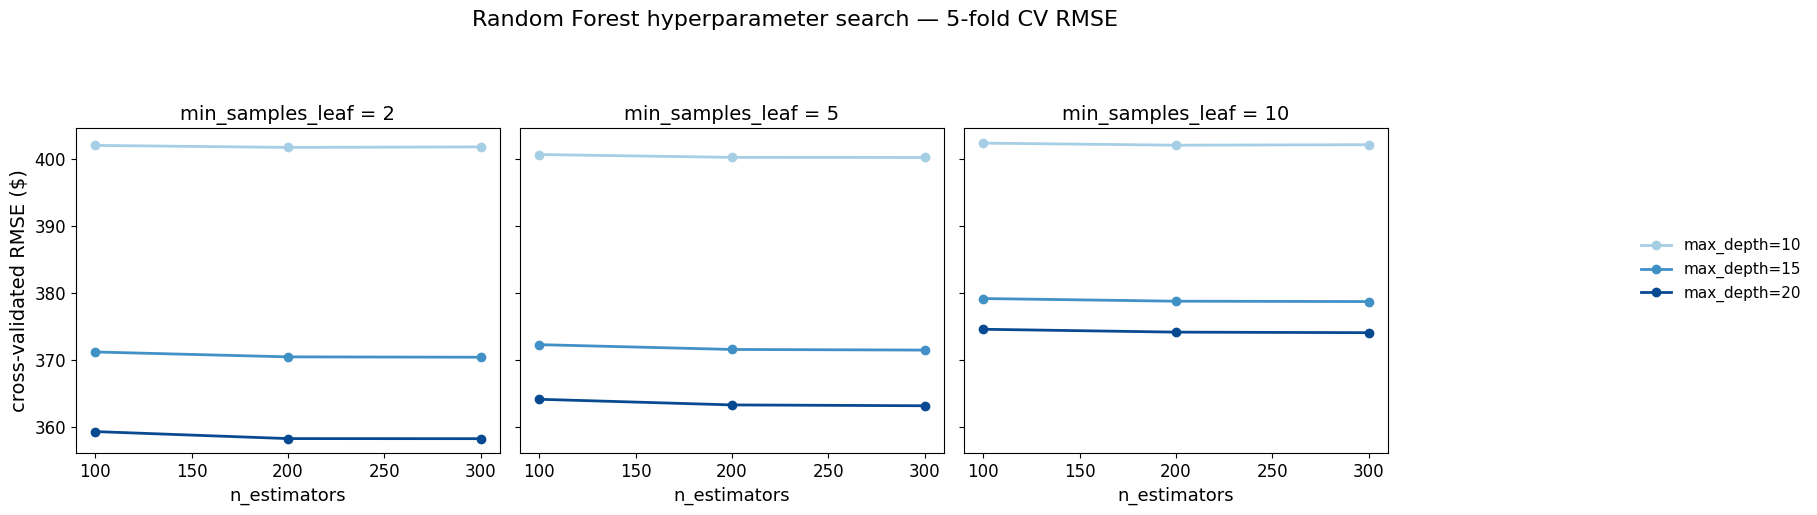

In [3]:
results = rf_grid.cv_results_
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

leaf_values = [2, 5, 10]
depth_values = [10, 15, 20]
blues = plt.cm.Blues(np.linspace(0.35, 0.90, len(depth_values)))
depth_labels = {10: "max_depth=10", 15: "max_depth=15",
                20: "max_depth=20"}

handles, labels = [], []
for depth, color in zip(depth_values, blues):
    for leaf, ax in zip(leaf_values, axes):
        mask = (np.array(results["param_regressor__min_samples_leaf"]) == leaf) & \
               (np.array(results["param_regressor__max_depth"]) == depth)
        n_est = np.array(results["param_regressor__n_estimators"])[mask]
        rmse  = -np.array(results["mean_test_score"])[mask]
        order = np.argsort(n_est)
        line, = ax.plot(n_est[order], rmse[order], marker="o",
                       color=color, linewidth=2)
        if leaf == leaf_values[0]:
            handles.append(line)
            labels.append(depth_labels[depth])
    axes[0].set_ylabel("cross-validated RMSE ($)", fontsize=14)

for leaf, ax in zip(leaf_values, axes):
    ax.set_title(f"min_samples_leaf = {leaf}", fontsize=14)
    ax.set_xlabel("n_estimators", fontsize=13)
    ax.tick_params(axis="both", labelsize=12)

# Mark the best model in the left panel
best_depth = rf_grid.best_params_["regressor__max_depth"]
best_n     = rf_grid.best_params_["regressor__n_estimators"]
if best_depth is None:
    axes[0].axvline(best_n, color="grey", linestyle="--", linewidth=1)

fig.suptitle("Random Forest hyperparameter search — 5-fold CV RMSE", fontsize=16, y=1.02)
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
           fontsize=11, frameon=False)
fig.tight_layout(rect=[0, 0, 0.88, 0.93])
fig.savefig("../outputs/figures/rf_hyperparameter_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [4]:
from src.modelling import evaluate_model

# X_test_transformed, not XX_test - the pipeline includes its own preprocessor
rf_metrics = evaluate_model(rf_grid.best_estimator_, X_test_transformed, y_test)

print(f"RMSE : ${rf_metrics['rmse']:,.2f}")
print(f"MAE  : ${rf_metrics['mae']:,.2f}")
print(f"R2   : {rf_metrics['r2']:.4f}")

RMSE : $384.07
MAE  : $185.62
R2   : 0.7903


**Figure: predicted vs actual price — Random Forest diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

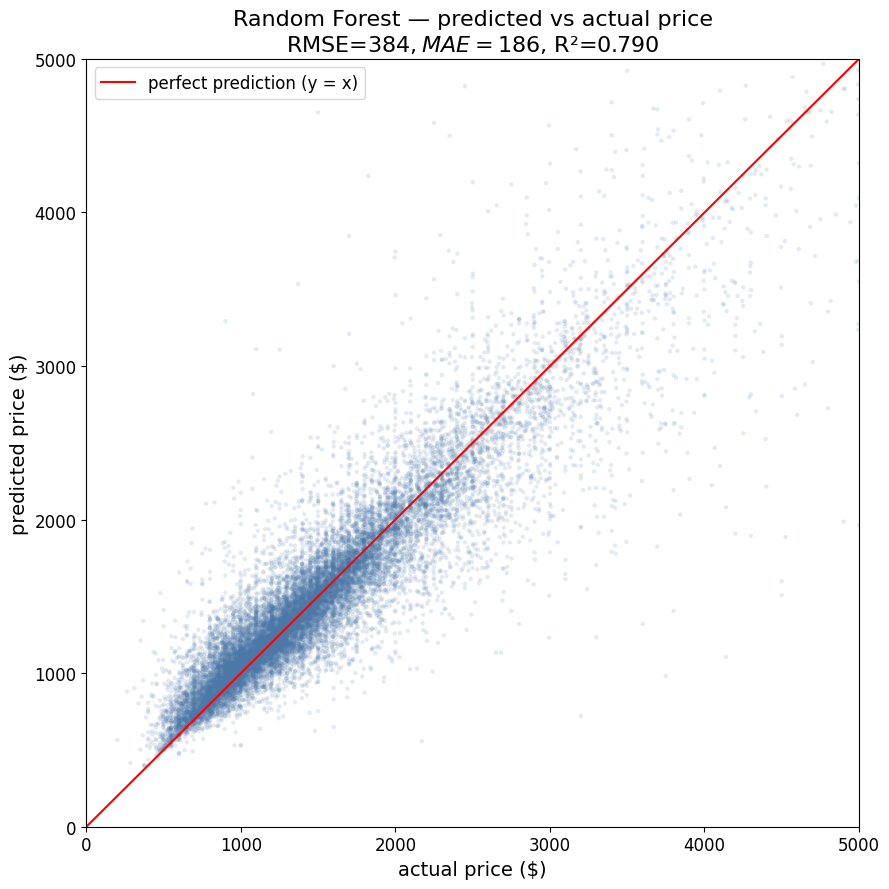

In [5]:
y_pred = rf_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C78A8", edgecolors="none")

limits = [0, 5000]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"Random Forest — predicted vs actual price\n"
             f"RMSE=${rf_metrics['rmse']:,.0f}, MAE=${rf_metrics['mae']:,.0f}, "
             f"R²={rf_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/rf_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()

---

## Gradient Boosting Modelling (XGBoost)

Gradient Boosting builds trees sequentially, where each new tree corrects the
residual errors of the ensemble so far. Like Random Forest it is tree-based
and scale-invariant, so this section reuses the unscaled preprocessor
(`scale_numeric=False`) from the Random Forest section — cityname is still
target-encoded the same way as in Shared Setup. `n_estimators`, `max_depth`
and `learning_rate` are tuned together by 5-fold cross-validation: more/deeper
trees increase capacity, while a lower learning rate trades training speed for
generalisation.

In [ ]:
from src.modelling import train_xgboost

# Trees are scale-invariant, so this section reuses the unscaled preprocessor
# (scale_numeric=False), same as Random Forest.
xgb_preprocessor_path = MODELS_DIR / "preprocessor_unscaled.pkl"

# Flip to True whenever XGB_PARAM_GRID (in src/modelling.py) or anything upstream
# of it changes — otherwise the cached grid search below is loaded instead of rerun.
RETRAIN_XGB = False

xgb_path = MODELS_DIR / "xgboost.pkl"

if RETRAIN_XGB or not xgb_path.exists():
    xgb_preprocessor = build_preprocessor(numeric, categorical, city, scale_numeric=False)
    
    # Pass preprocessor directly into the function
    xgb_grid = train_xgboost(X_train_transformed, y_train, preprocessor=xgb_preprocessor)

    # Save only the pipeline object (preprocessor is bundled inside it)
    joblib.dump(xgb_grid, xgb_path)
    print("Trained and saved XGBoost ->", xgb_path)
else:
    xgb_grid = joblib.load(xgb_path)
    print("Loaded cached XGBoost <-", xgb_path)

print("Best parameters :", xgb_grid.best_params_)
print(f"Best CV RMSE    : ${-xgb_grid.best_score_:,.2f}")

Loaded cached XGBoost <- ..\models\xgboost.pkl
Best parameters : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500}
Best CV RMSE    : $351.73


**Figure: hyperparameter search — evidence for tuning.**
Cross-validated RMSE for every `n_estimators`/`learning_rate` combination, one
panel per `max_depth`. Lower learning rates (darker teal) generally need more
trees to reach the same RMSE; the selected model is marked with a dashed
line.

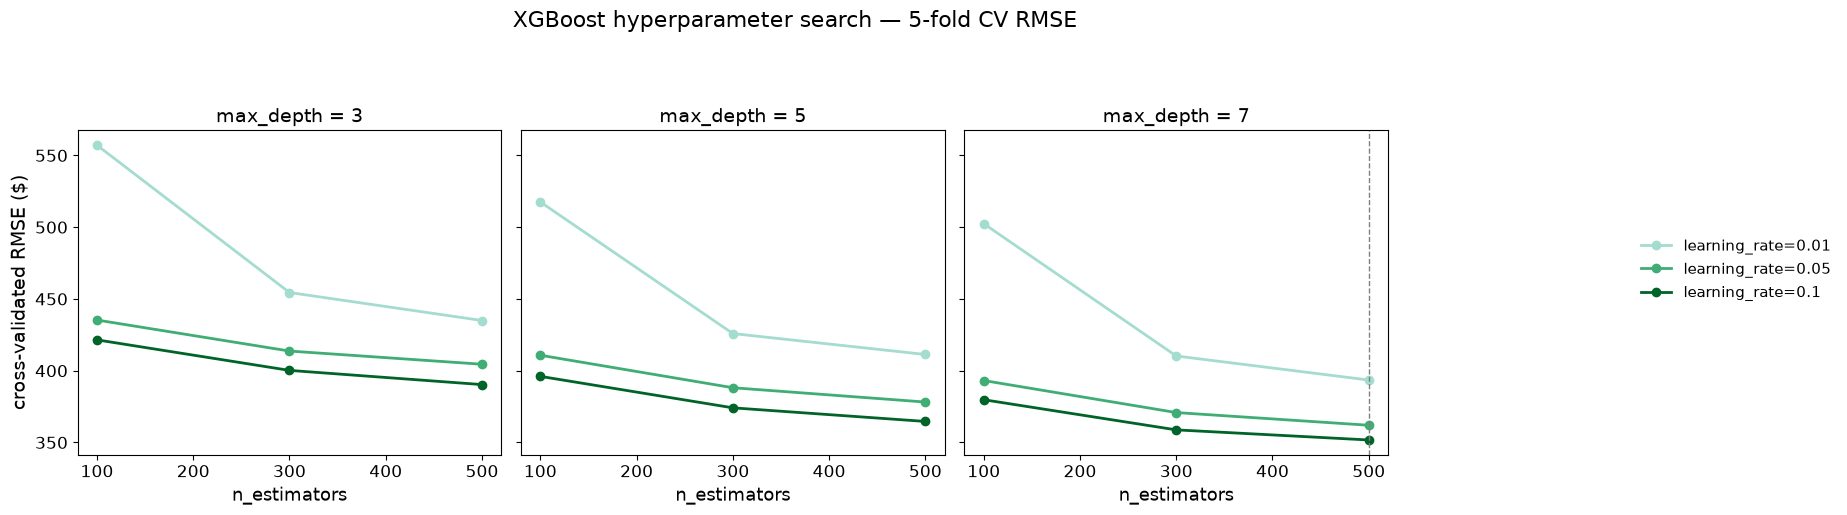

In [14]:
results = xgb_grid.cv_results_
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

depth_values = [3, 5, 7]
lr_values = [0.01, 0.05, 0.1]
teals = plt.cm.BuGn(np.linspace(0.35, 0.90, len(lr_values)))
lr_labels = {0.01: "learning_rate=0.01", 0.05: "learning_rate=0.05", 0.1: "learning_rate=0.1"}

handles, labels = [], []
for lr, color in zip(lr_values, teals):
    for depth, ax in zip(depth_values, axes):
        mask = (np.array(results["param_learning_rate"]) == lr) & \
               (np.array(results["param_max_depth"]) == depth)
        n_est = np.array(results["param_n_estimators"])[mask]
        rmse  = -np.array(results["mean_test_score"])[mask]
        order = np.argsort(n_est)
        line, = ax.plot(n_est[order], rmse[order], marker="o",
                        color=color, linewidth=2)
        if depth == depth_values[0]:
            handles.append(line)
            labels.append(lr_labels[lr])
    axes[0].set_ylabel("cross-validated RMSE ($)", fontsize=14)

for depth, ax in zip(depth_values, axes):
    ax.set_title(f"max_depth = {depth}", fontsize=14)
    ax.set_xlabel("n_estimators", fontsize=13)
    ax.tick_params(axis="both", labelsize=12)

best_depth_idx = depth_values.index(xgb_grid.best_params_["max_depth"])
best_n = xgb_grid.best_params_["n_estimators"]
axes[best_depth_idx].axvline(best_n, color="grey", linestyle="--", linewidth=1)

fig.suptitle("XGBoost hyperparameter search — 5-fold CV RMSE", fontsize=16, y=1.02)
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5),
           fontsize=11, frameon=False)
fig.tight_layout(rect=[0, 0, 0.88, 0.93])
fig.savefig("../outputs/figures/xgb_hyperparameter_search.png", dpi=200, bbox_inches="tight")
plt.show()

### Test-set performance

The tuned model is scored once on the held-out 20% test split, which it has not
seen at any point during cleaning, transformation or tuning.

In [15]:
from src.modelling import evaluate_model

# best_estimator_ is now a bare XGBRegressor (train_xgboost takes already-
# preprocessed data, same convention as train_knn), so X_test must be passed
# through the same fitted xgb_preprocessor before scoring - it is NOT baked
# into best_estimator_ the way it was in the old Pipeline version.
X_test_xgb = xgb_preprocessor.transform(X_test_transformed)
xgb_metrics = evaluate_model(xgb_grid.best_estimator_, X_test_xgb, y_test)

print(f"RMSE : ${xgb_metrics['rmse']:,.2f}")
print(f"MAE  : ${xgb_metrics['mae']:,.2f}")
print(f"R2   : {xgb_metrics['r2']:.4f}")

RMSE : $373.35
MAE  : $189.81
R2   : 0.8018


**Figure: predicted vs actual price — XGBoost diagnostic.**
Each point is one test listing. The red line is `y = x` (a perfect prediction).
Points below the line are under-predictions; the spread away from the line shows
where the model is least reliable.

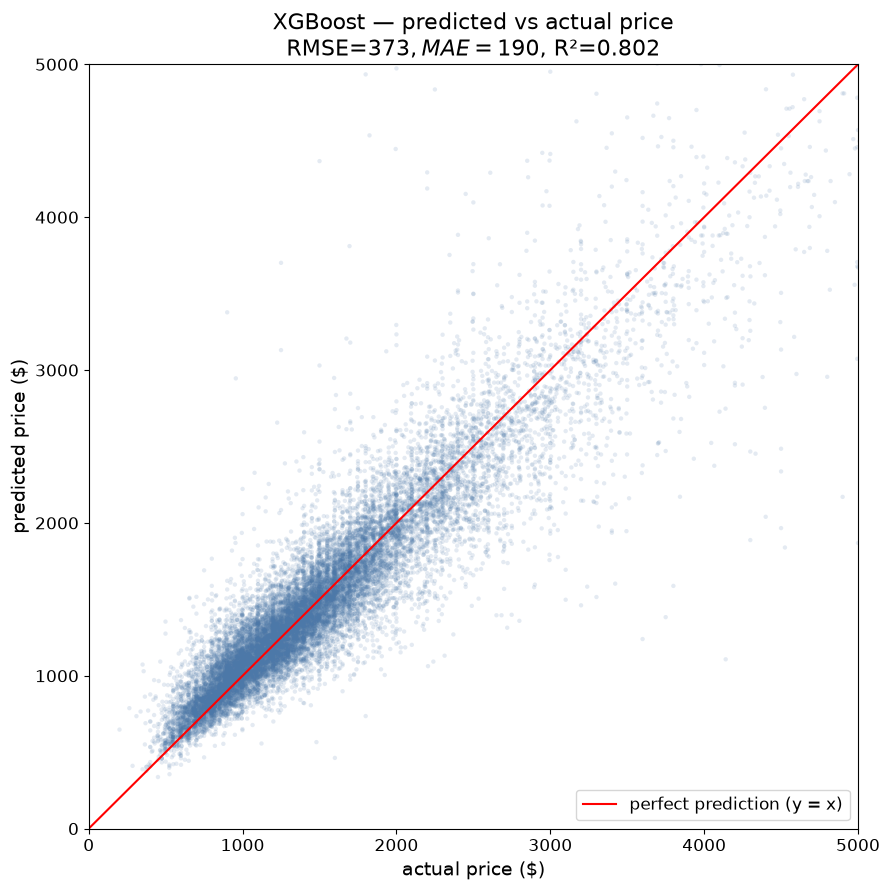

In [16]:
y_pred = xgb_metrics["predictions"]
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C78A8", edgecolors="none")

limits = [0, 5000]
ax.plot(limits, limits, color="red", linewidth=1.5, label="perfect prediction (y = x)")

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel("actual price ($)", fontsize=14)
ax.set_ylabel("predicted price ($)", fontsize=14)
ax.set_title(f"XGBoost — predicted vs actual price\n"
             f"RMSE=${xgb_metrics['rmse']:,.0f}, MAE=${xgb_metrics['mae']:,.0f}, "
             f"R\u00b2={xgb_metrics['r2']:.3f}", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=12)

fig.tight_layout()
fig.savefig("../outputs/figures/xgb_pred_vs_actual.png", dpi=200, bbox_inches="tight")
plt.show()